## Problem Statement
##### This project aims to predict the survival outcome of breast cancer patients using machine learning models based on clinical and diagnostic features. By analysing historical medical data, the system classifies whether a patient is likely to survive or not.

##### Target Variable: Patient_Status

## 1.Import Libraries


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Load dataset
df = pd.read_csv("data.csv")
df.head()


,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


In [ ]:
df[df.duplicated()].shape

(0, 15)

## 2.Dataset information

###### 2.1 Age : Age of the patient 
###### 2. Gender : Patient’s gender (FEMALE / MALE)
###### 3.Protein1-4 : expression levels
###### 4.Tumour_Stage : Breast cancer stage of the patien
###### 5.Histology : Microscopic type of tumor (how cancer cells look under microscope)     
###### 6.ER status : Positive/Negative   
###### 7.PR status : Positive/Negative       
###### 8.HER2 status : a gene/protein related to cancer growth(positive/Negative)     
###### 9.Surgery_type  :  Type of surgery    
###### 10.Date_of_Surgery :  Date when surgery was performed  
###### 11.Date_of_Last_Visit :Last recorded follow-up date
###### 12.Patient_Status : Target Variable

In [ ]:
df.shape

(334, 15)

In [ ]:
df.size

5010

## 3.3 Check data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 334 non-null    int64  
 1   Gender              334 non-null    object 
 2   Protein1            334 non-null    float64
 3   Protein2            334 non-null    float64
 4   Protein3            334 non-null    float64
 5   Protein4            334 non-null    float64
 6   Tumour_Stage        334 non-null    object 
 7   Histology           334 non-null    object 
 8   ER status           334 non-null    object 
 9   PR status           334 non-null    object 
 10  HER2 status         334 non-null    object 
 11  Surgery_type        334 non-null    object 
 12  Date_of_Surgery     334 non-null    object 
 13  Date_of_Last_Visit  317 non-null    object 
 14  Patient_Status      321 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory usage: 39.3+ K

In [ ]:
df.describe()

,Age,Protein1,Protein2,Protein3,Protein4
count,334.000000,334.000000,334.000000,334.000000,334.000000
mean,58.886228,-0.029991,0.946896,-0.090204,0.009819
std,12.961212,0.563588,0.911637,0.585175,0.629055
min,29.000000,-2.340900,-0.978730,-1.627400,-2.025500
25%,49.000000,-0.358888,0.362173,-0.513748,-0.377090
50%,58.000000,0.006129,0.992805,-0.173180,0.041768
75%,68.000000,0.343598,1.627900,0.278353,0.425630
max,90.000000,1.593600,3.402200,2.193400,1.629900


### Insights from Numerical Data
###### From the above statistical summary, the Age of patients ranges from 29 to 90 years, with an average age of approximately 58.89 years, indicating that the dataset mainly contains middle-aged to elderly individuals.
###### The distribution of Protein1 values has a mean of -0.03 and ranges from -2.34 to 1.59, showing that the values are slightly centered around zero with moderate variation.
###### Protein2 shows a relatively higher mean (0.95) compared to other protein features, and its values vary between -0.98 and 3.40, indicating a wider spread and possible positive skewness.
###### Protein3 has a mean of -0.09, ranging from -1.63 to 2.19, suggesting that most values are slightly concentrated below zero but still have moderate variability.
###### Protein4 has a mean close to zero (0.0098) and ranges from -2.02 to 1.63, indicating a nearly centered distribution with balanced spread.
###### The standard deviation values across all protein features (around 0.56 to 0.91) indicate that the data has moderate variability, meaning no extreme dispersion is observed.
###### The median (50%) values for all features are very close to their means, suggesting that the distributions are fairly symmetrical with no extreme skewness.

In [ ]:
df.describe(include='all')

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
count,334.000000,334,334.000000,334.000000,334.000000,334.000000,334,334,334,334,334,334,334,317,321
unique,NaN,2,NaN,NaN,NaN,NaN,3,3,1,1,2,4,181,285,2
top,NaN,FEMALE,NaN,NaN,NaN,NaN,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,13-Feb-21,Alive
freq,NaN,330,NaN,NaN,NaN,NaN,189,233,334,334,305,105,5,3,255
mean,58.886228,NaN,-0.029991,0.946896,-0.090204,0.009819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,12.961212,NaN,0.563588,0.911637,0.585175,0.629055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,29.000000,NaN,-2.340900,-0.978730,-1.627400,-2.025500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,49.000000,NaN,-0.358888,0.362173,-0.513748,-0.377090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,58.000000,NaN,0.006129,0.992805,-0.173180,0.041768,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,68.000000,NaN,0.343598,1.627900,0.278353,0.425630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## handling missing value

In [ ]:
df.isnull().sum()

Age                    0
Gender                 0
Protein1               0
Protein2               0
Protein3               0
Protein4               0
Tumour_Stage           0
Histology              0
ER status              0
PR status              0
HER2 status            0
Surgery_type           0
Date_of_Surgery        0
Date_of_Last_Visit    17
Patient_Status        13
dtype: int64

#### there are present missing values in thedataset

In [ ]:
df.isnull().sum()/(df.shape[0])*100

Age                   0.000000
Gender                0.000000
Protein1              0.000000
Protein2              0.000000
Protein3              0.000000
Protein4              0.000000
Tumour_Stage          0.000000
Histology             0.000000
ER status             0.000000
PR status             0.000000
HER2 status           0.000000
Surgery_type          0.000000
Date_of_Surgery       0.000000
Date_of_Last_Visit    5.089820
Patient_Status        3.892216
dtype: float64

In [ ]:
(df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100)

np.float64(0.5988023952095809)

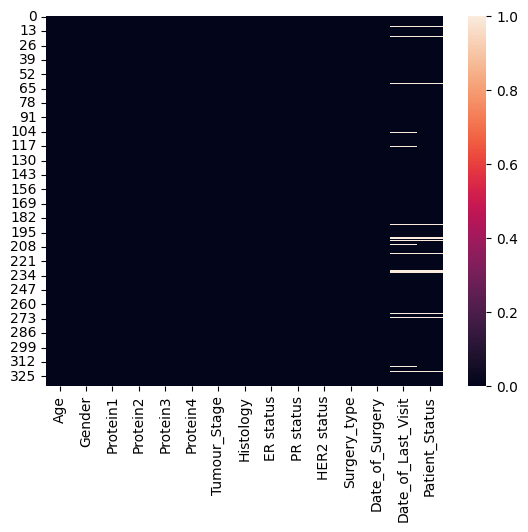

In [ ]:
sns.heatmap(df.isnull())
plt.show()

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
const_cols = [col for col in df.columns if df[col].nunique() == 1]
print('Dropping constant columns:', const_cols)
df = df.drop(columns=const_cols)

Dropping constant columns: ['ER status', 'PR status']


#### - ER status and PR status had only one value(Positive)  → no predictive power → dropped

In [ ]:
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


In [ ]:
df.shape

(334, 13)

In [ ]:
# Convert Date
df['Date_of_Surgery'] = pd.to_datetime(df['Date_of_Surgery'], errors='coerce')
df['Date_of_Last_Visit'] = pd.to_datetime(df['Date_of_Last_Visit'], errors='coerce')

In [ ]:
# Feature engineering
df['Survived_Days'] = (df['Date_of_Last_Visit'] - df['Date_of_Surgery']).dt.days

##### - Created survival duration feature
##### - Helps understand patient survival patterns
##### - ⚠️ Will be removed later due to data leakage

In [ ]:
df[['Date_of_Surgery','Date_of_Last_Visit']].isnull().sum()

Date_of_Surgery        0
Date_of_Last_Visit    17
dtype: int64

In [ ]:
# For categorical
df = df.dropna(subset=['Patient_Status'])

In [ ]:
df = df.drop(columns=['Date_of_Surgery','Date_of_Last_Visit'])

In [ ]:
df = df.drop(columns=['Survived_Days'])

In [ ]:
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,HER2 status,Surgery_type,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Negative,Other,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Negative,Other,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Negative,Lumpectomy,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Negative,Other,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Lumpectomy,Alive


In [ ]:
df.isnull().sum()

Age               0
Gender            0
Protein1          0
Protein2          0
Protein3          0
Protein4          0
Tumour_Stage      0
Histology         0
HER2 status       0
Surgery_type      0
Patient_Status    0
dtype: int64

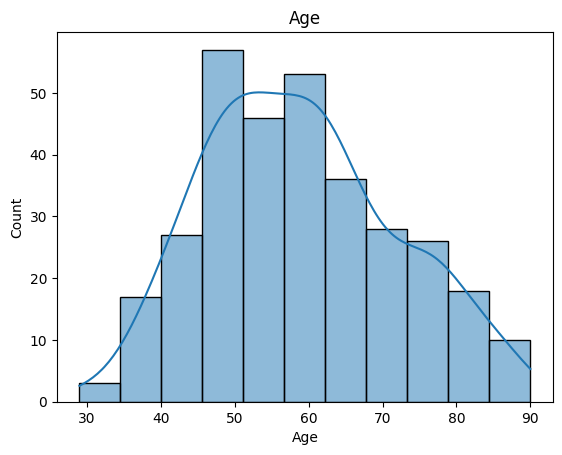

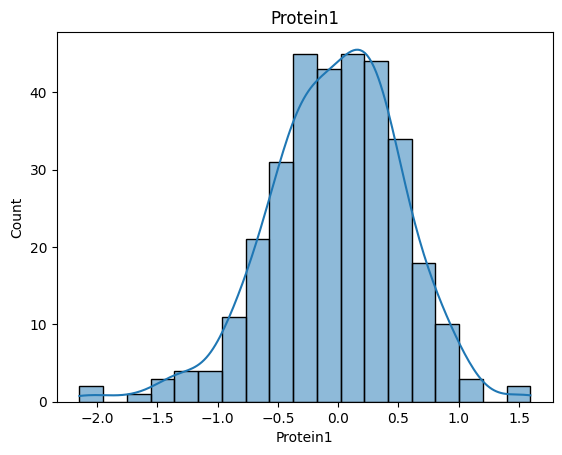

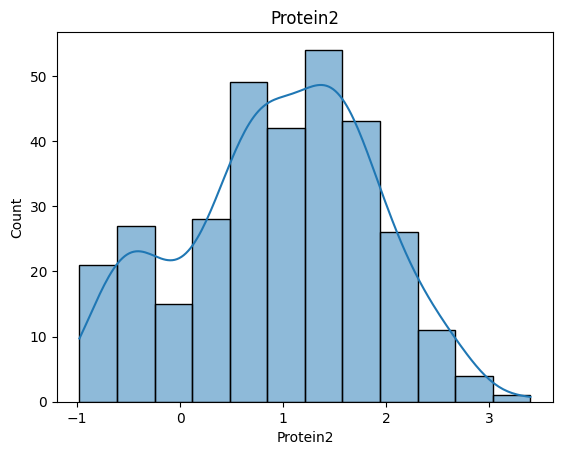

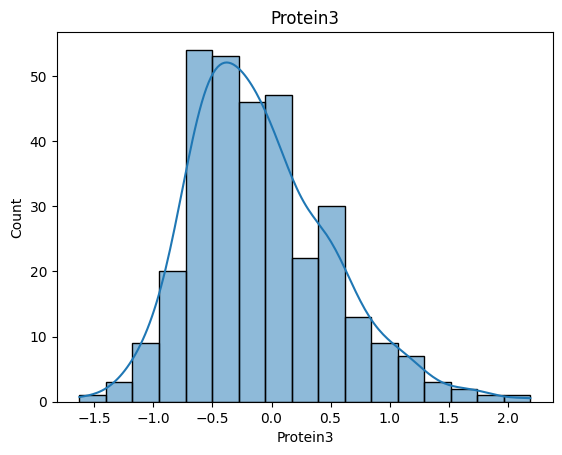

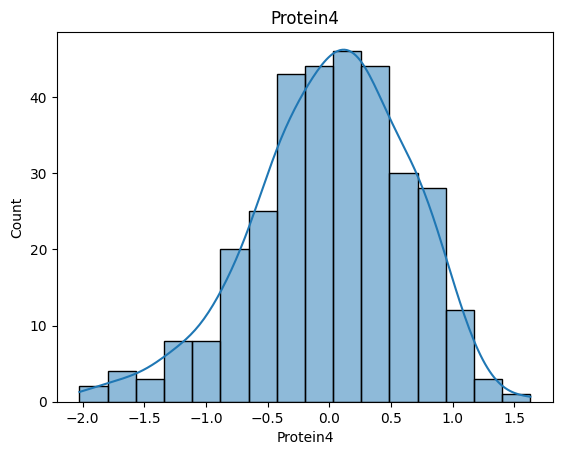

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols: 
    plt.figure()
    sns.histplot(df[col],kde=True)
    plt.title(col)
    plt.show()


 Frequency counts for Gender:
 Gender
FEMALE    317
MALE        4
Name: count, dtype: int64


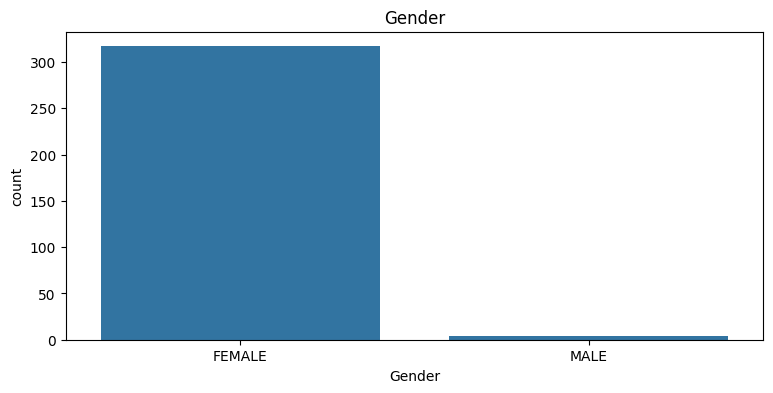


 Frequency counts for Tumour_Stage:
 Tumour_Stage
II     182
III     78
I       61
Name: count, dtype: int64


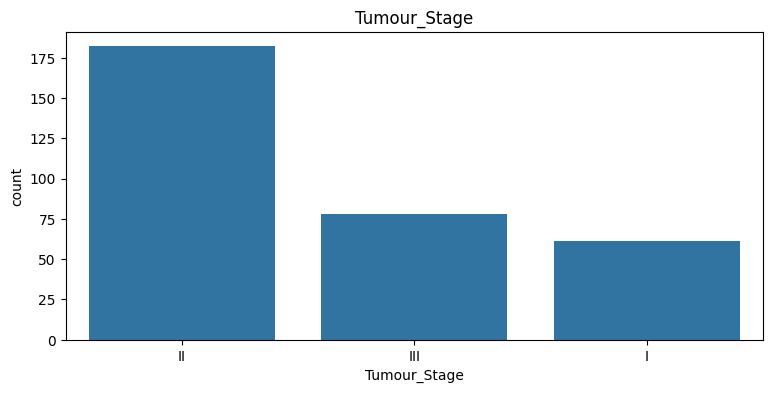


 Frequency counts for Histology:
 Histology
Infiltrating Ductal Carcinoma     226
Infiltrating Lobular Carcinoma     83
Mucinous Carcinoma                 12
Name: count, dtype: int64


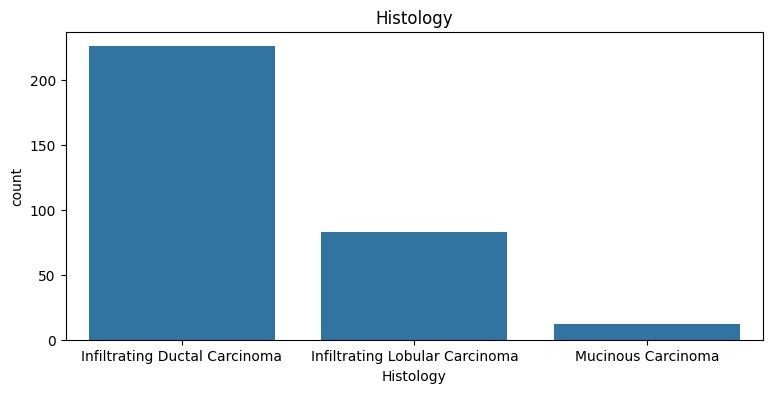


 Frequency counts for HER2 status:
 HER2 status
Negative    292
Positive     29
Name: count, dtype: int64


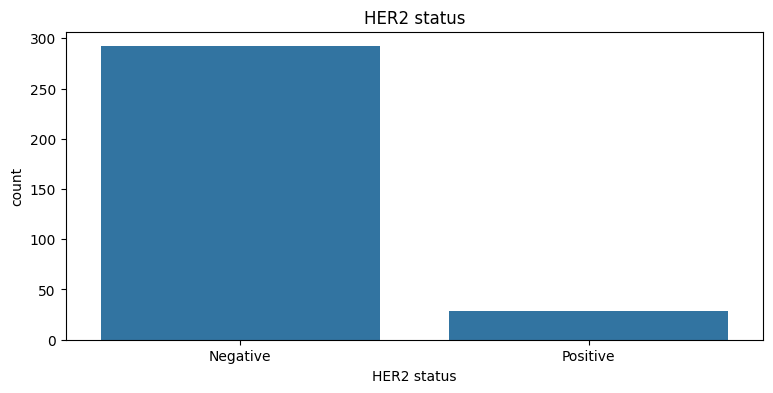


 Frequency counts for Surgery_type:
 Surgery_type
Other                          98
Modified Radical Mastectomy    92
Lumpectomy                     66
Simple Mastectomy              65
Name: count, dtype: int64


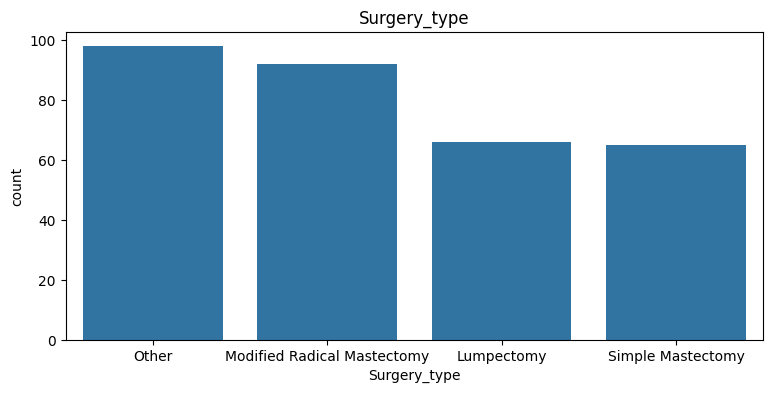


 Frequency counts for Patient_Status:
 Patient_Status
Alive    255
Dead      66
Name: count, dtype: int64


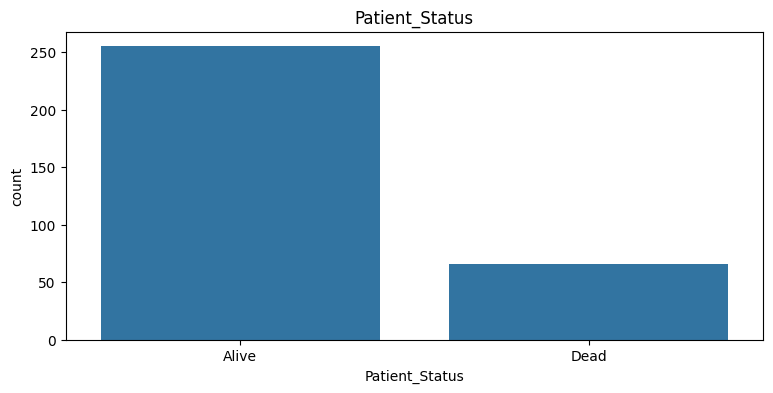

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for index, col in enumerate(cat_cols):
    print(f"\n Frequency counts for {col}:\n", df[col].value_counts())
    plt.figure(figsize=(9,4))
    sns.countplot(x =col,data=df,order=df[col].value_counts().index)
    plt.title(col)
    plt.show()

# Outlier_Detection

In [ ]:
df_num = df.select_dtypes(include= np.number)

In [ ]:
df_cat = df.select_dtypes(exclude= np.number)

In [ ]:
df_num.columns

Index(['Age', 'Protein1', 'Protein2', 'Protein3', 'Protein4'], dtype='object')

In [ ]:
df_cat.columns

Index(['Gender', 'Tumour_Stage', 'Histology', 'HER2 status', 'Surgery_type',
       'Patient_Status'],
      dtype='object')

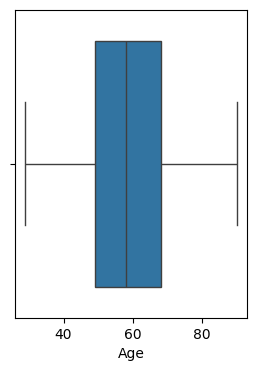

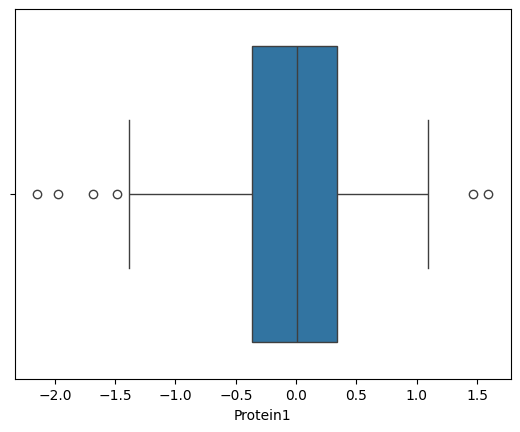

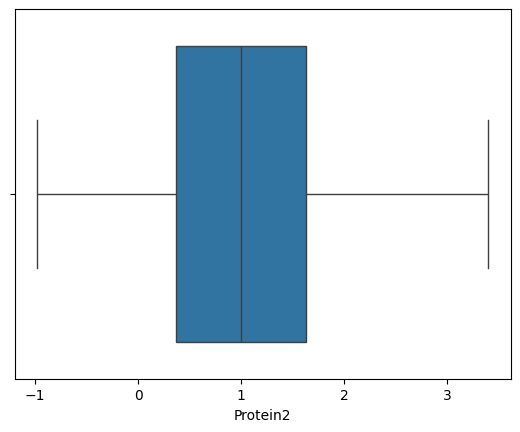

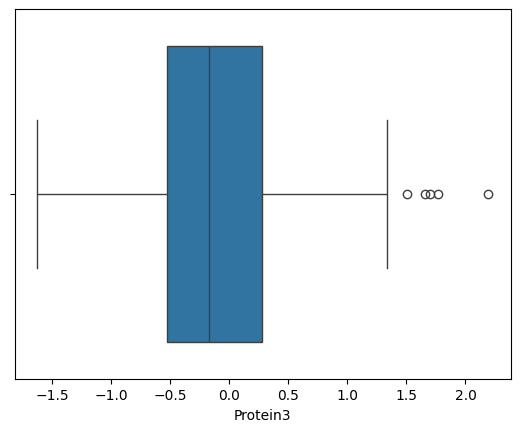

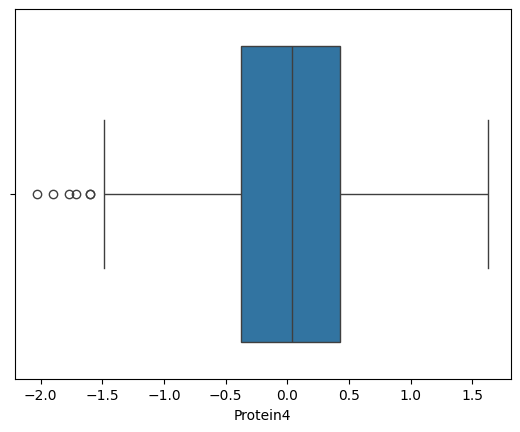

In [ ]:
plt.figure(figsize=(3,4))
for i in df_num.columns:
    sns.boxplot(x = df_num[i],data=df)
    plt.show()

In [ ]:
for i in df_num.columns:
    q1 = df_num[i].quantile(0.25)
    q3 = df_num[i].quantile(0.75)
    
    IQR = q3-q1
    
    min_range = q1-(1.5*IQR)
    max_range = q3+(1.5*IQR)
    
    df_num[i] = np.where(df_num[i]<min_range,min_range,df_num[i])
    df_num[i] = np.where(df_num[i]>max_range,max_range,df_num[i])
    

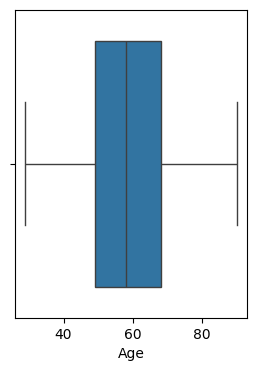

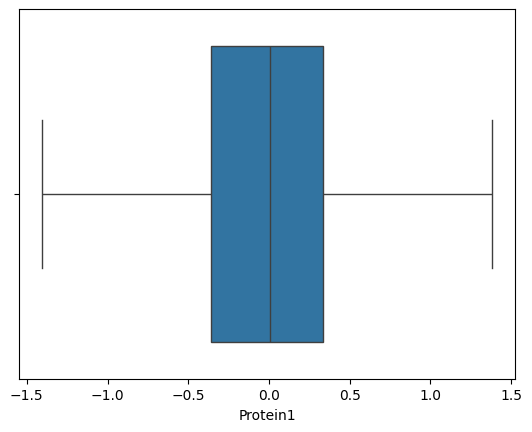

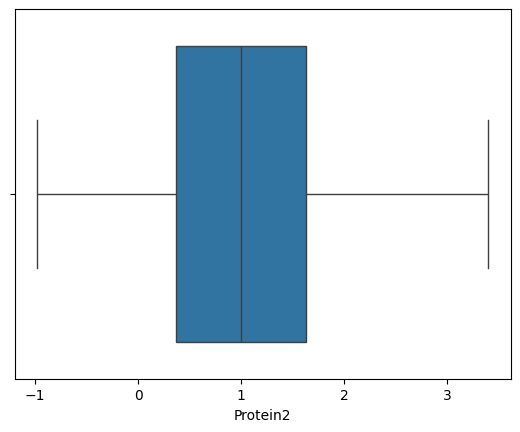

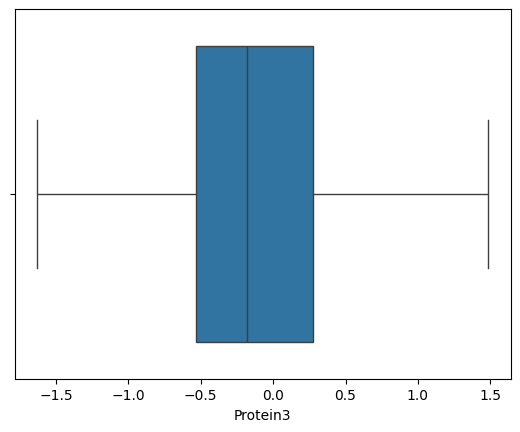

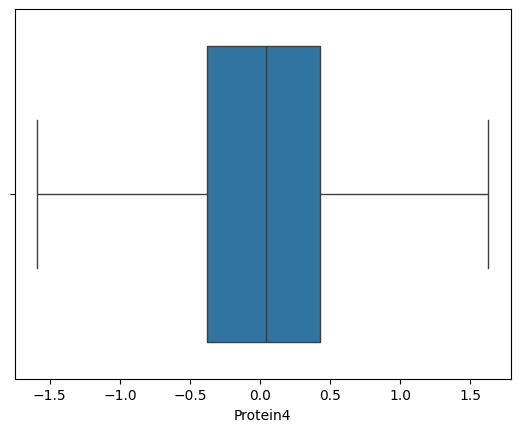

In [ ]:
plt.figure(figsize=(3,4))
for i in df_num.columns:
    sns.boxplot(x = df_num[i],data=df)
    plt.show()

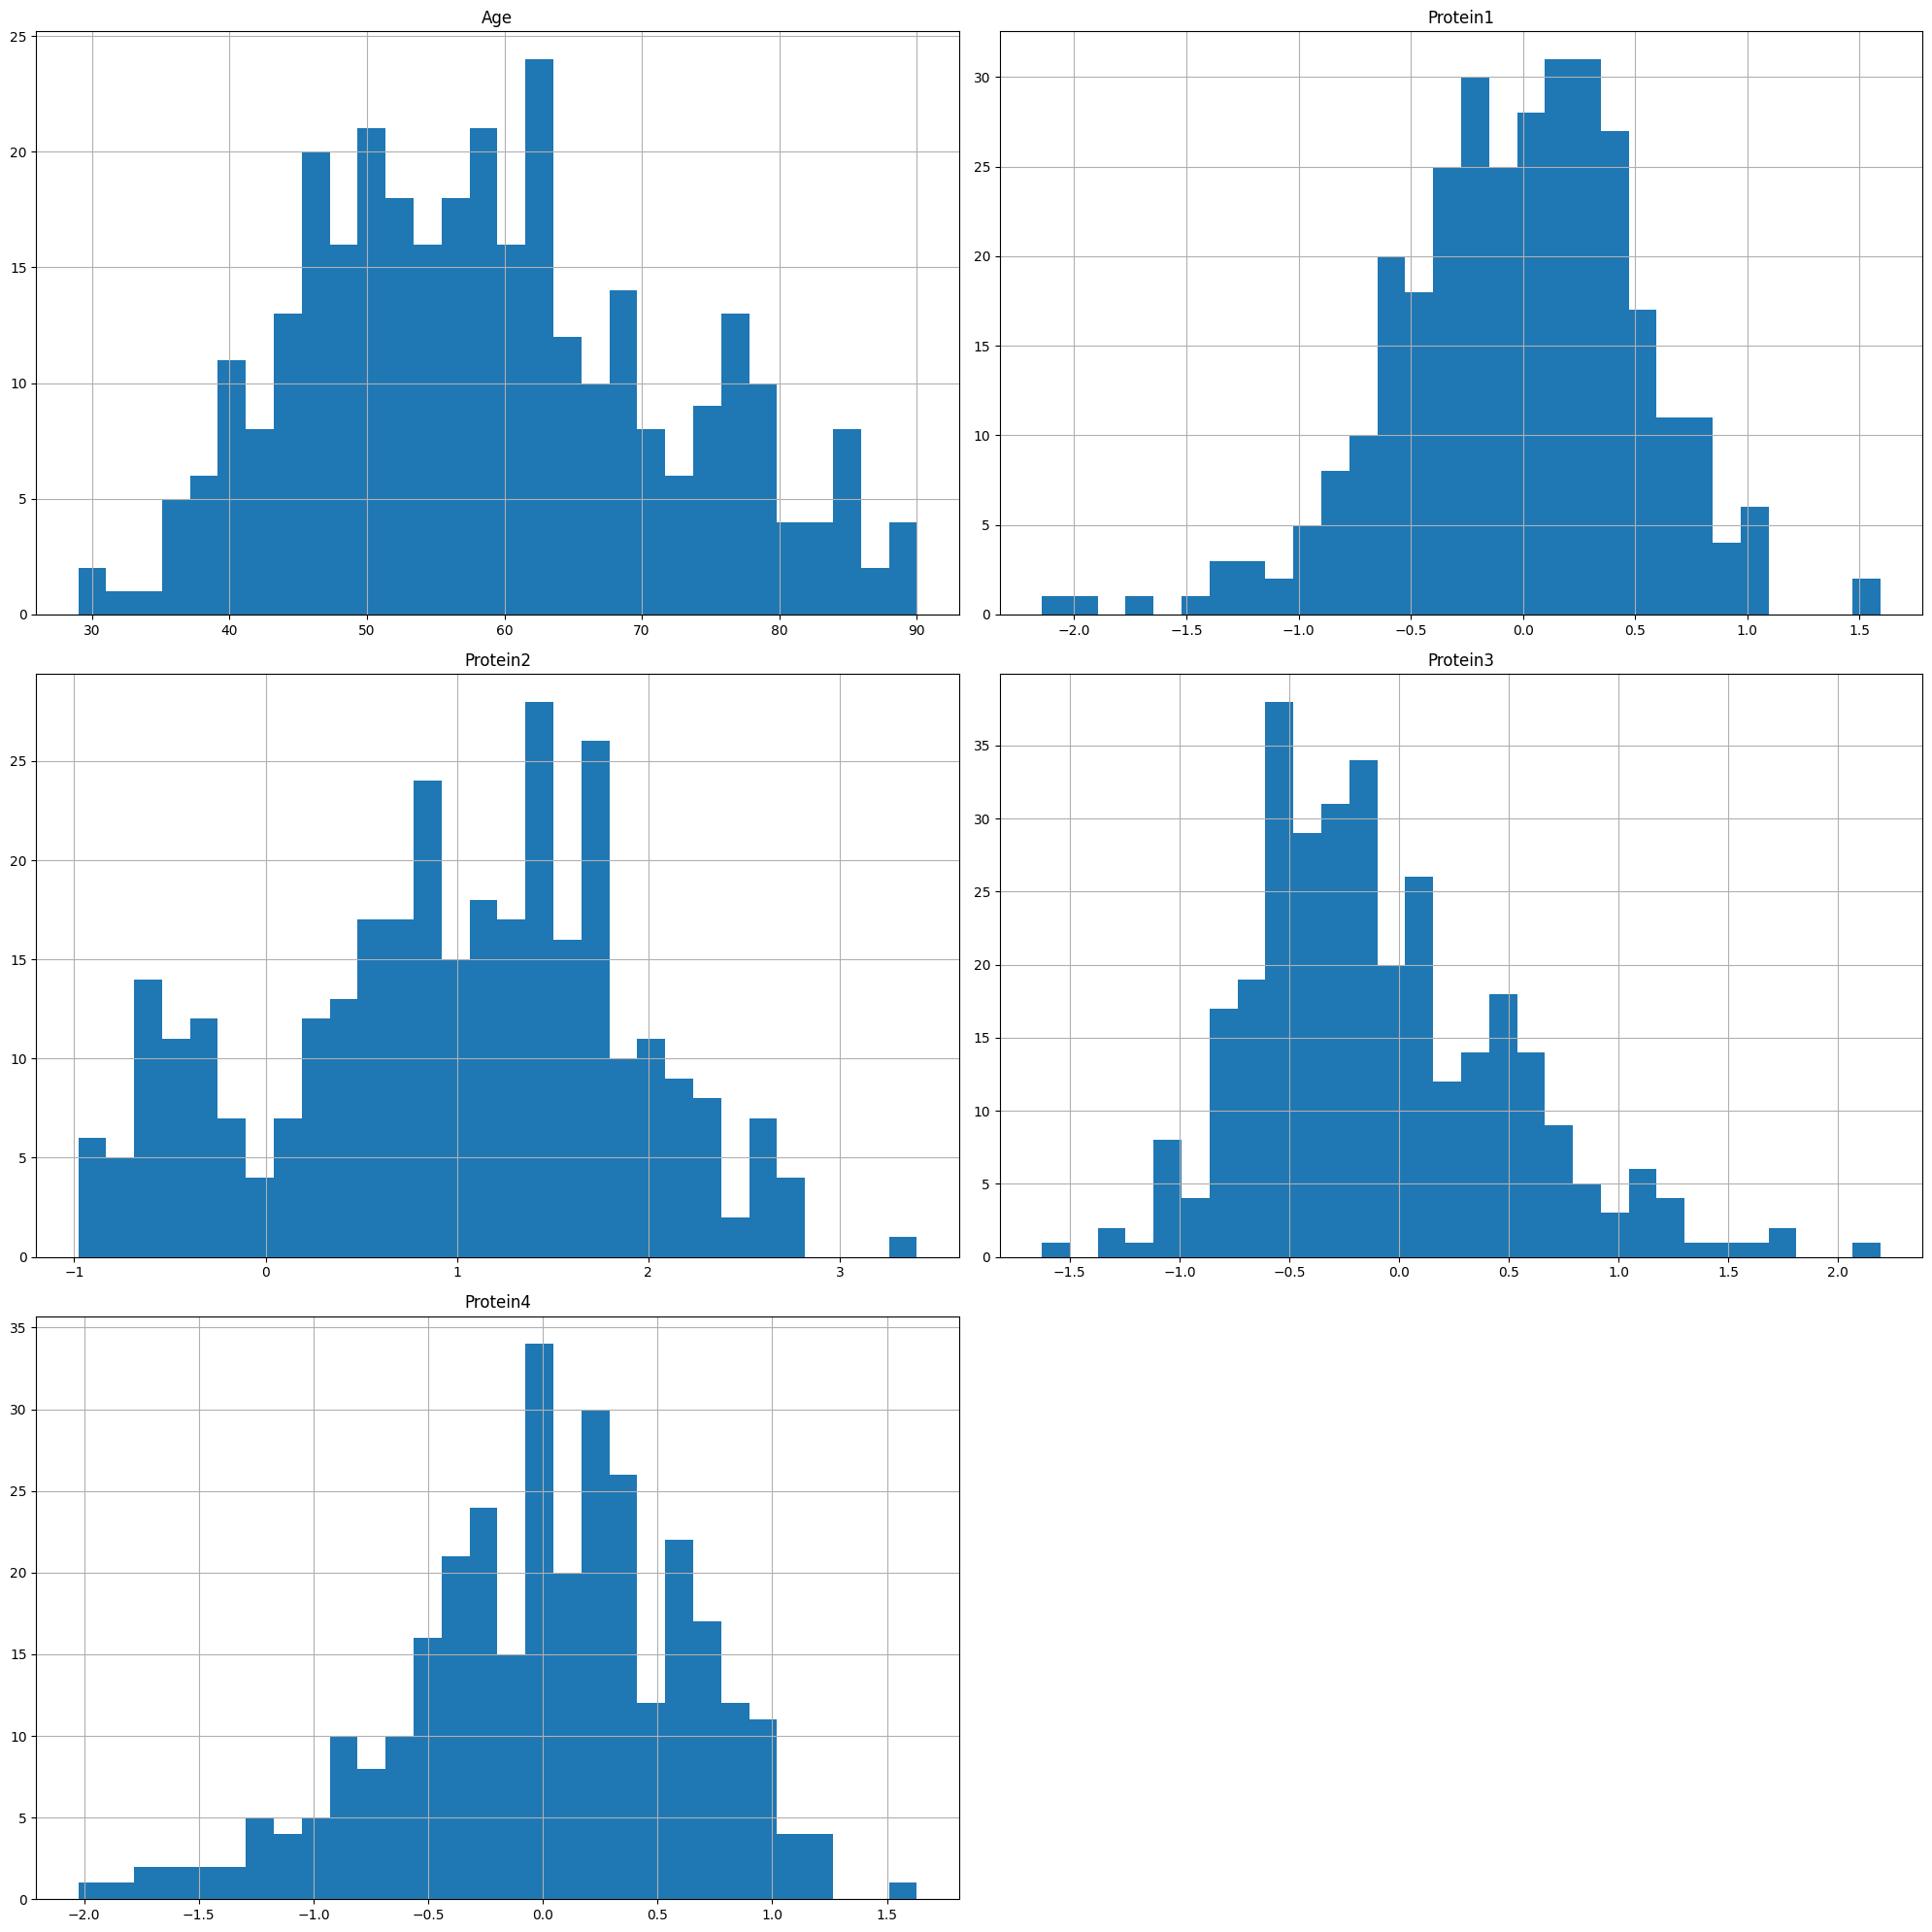

In [ ]:
df.hist(figsize=(20,20), bins=30)
plt.tight_layout()

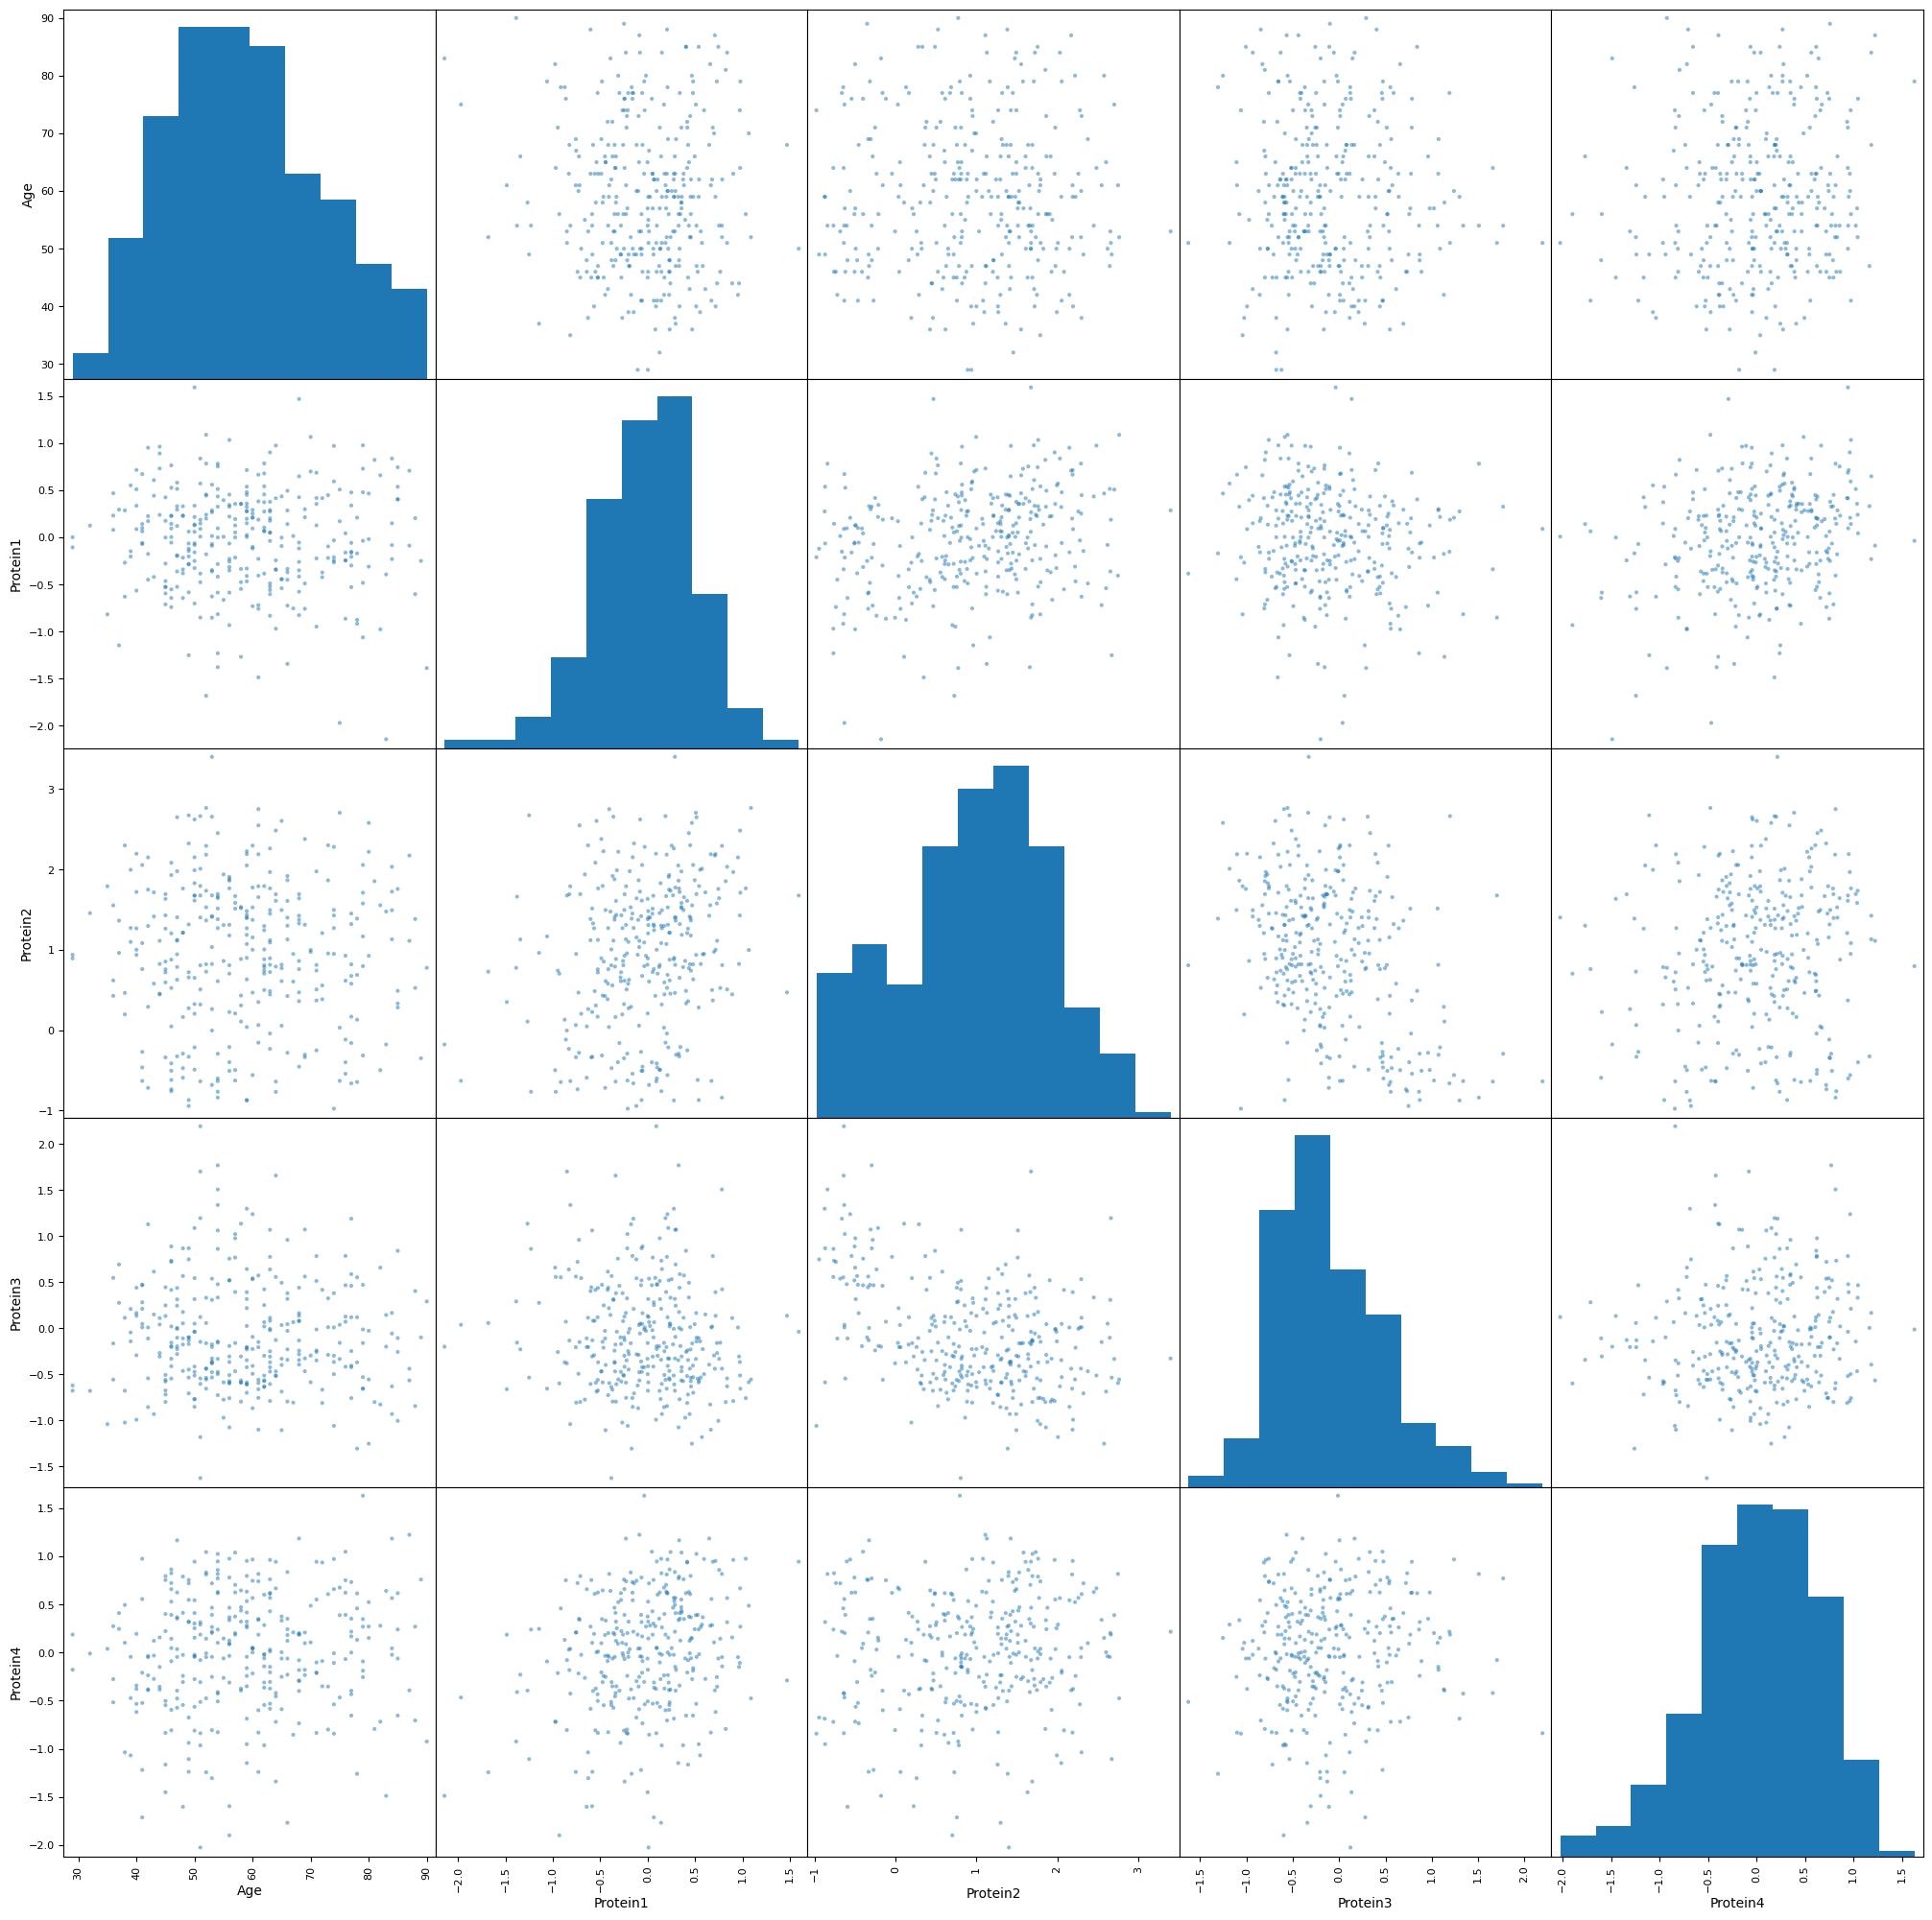

In [ ]:
from pandas.plotting import scatter_matrix
p=scatter_matrix(df,figsize=(25, 25))

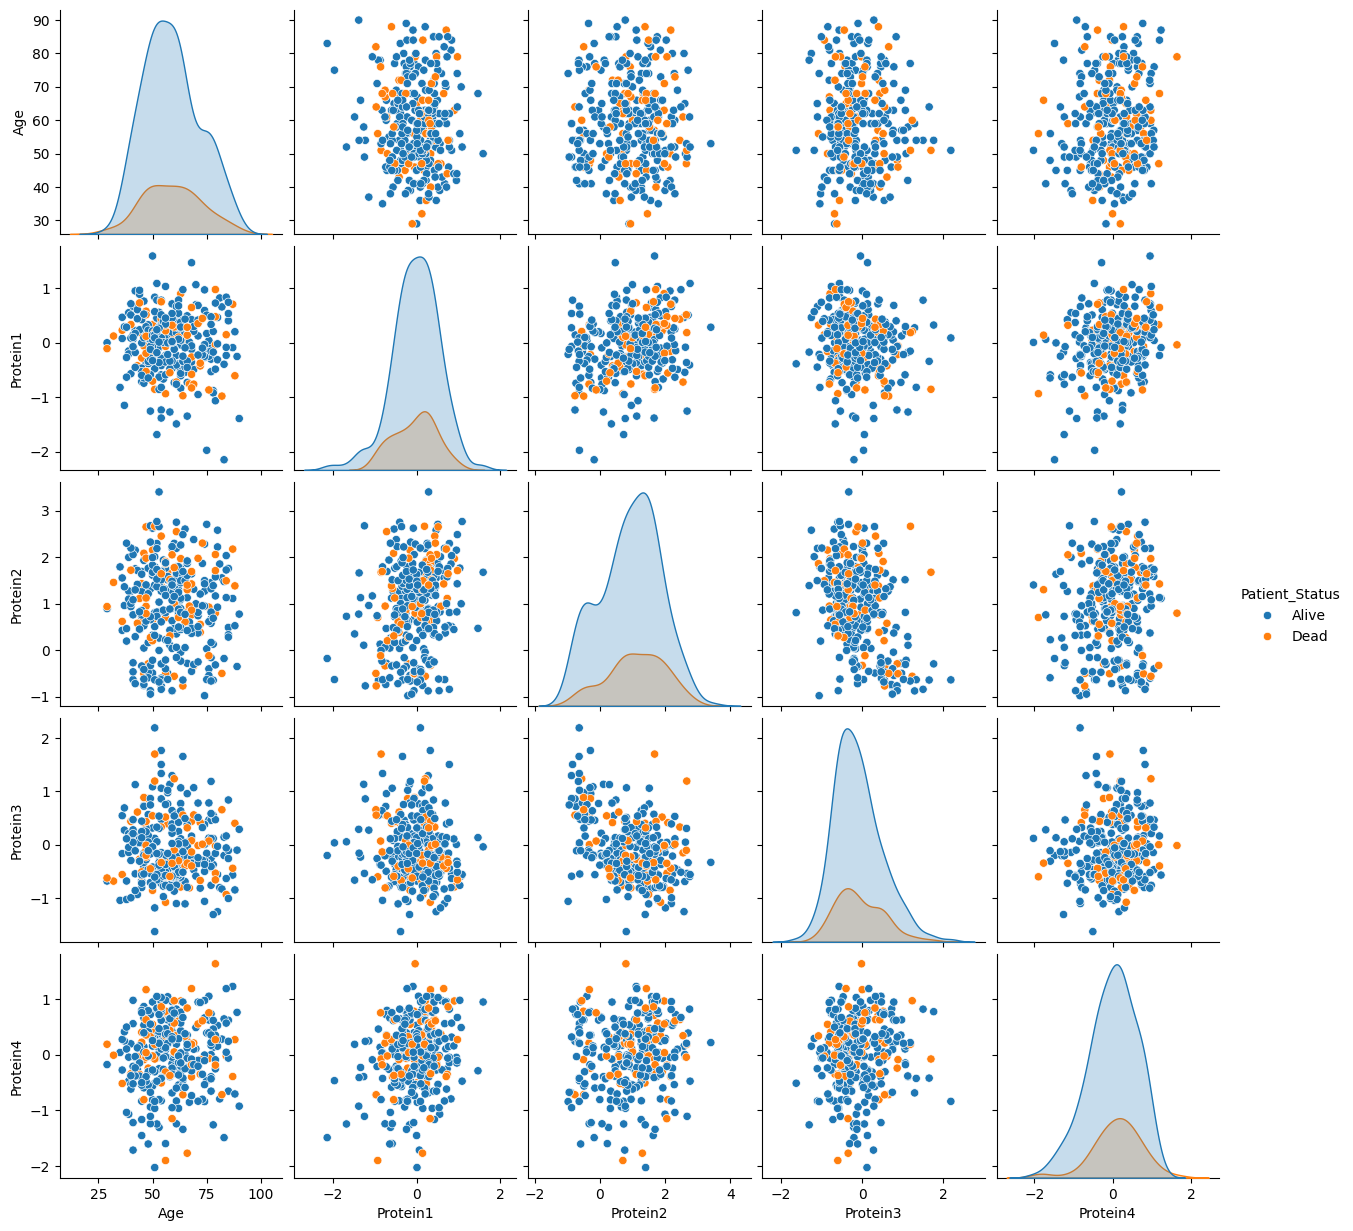

In [ ]:
p = sns.pairplot(df, hue = 'Patient_Status')

In [ ]:
#target variable
df.Patient_Status.value_counts()

Patient_Status
Alive    255
Dead      66
Name: count, dtype: int64

In [ ]:
df['Patient_Status'].value_counts(normalize=True)*100

Patient_Status
Alive    79.439252
Dead     20.560748
Name: proportion, dtype: float64

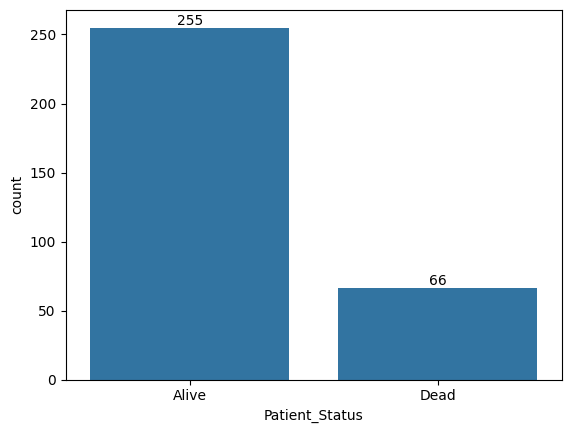

In [ ]:
ax = sns.countplot(x='Patient_Status', data=df)
ax.bar_label(ax.containers[0])
plt.show()

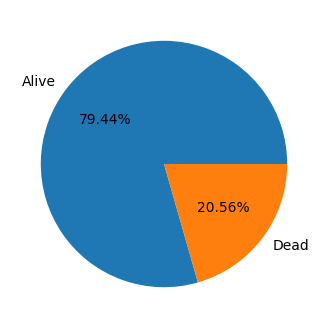

In [ ]:
plt.figure(figsize=(4,4))
gb = df.groupby('Patient_Status').agg({'Patient_Status':'count'})
plt.pie(gb['Patient_Status'], labels = gb.index, autopct = '%1.2f%%')
plt.show()

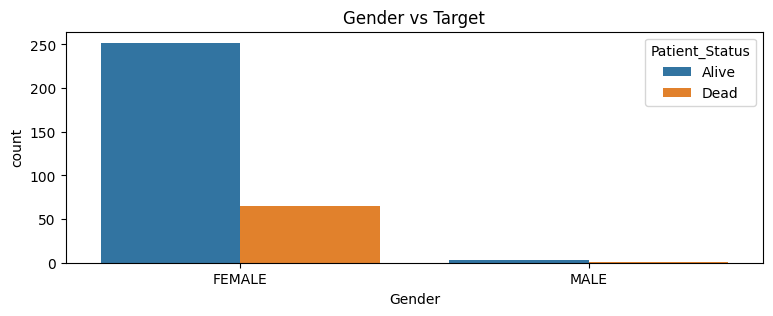

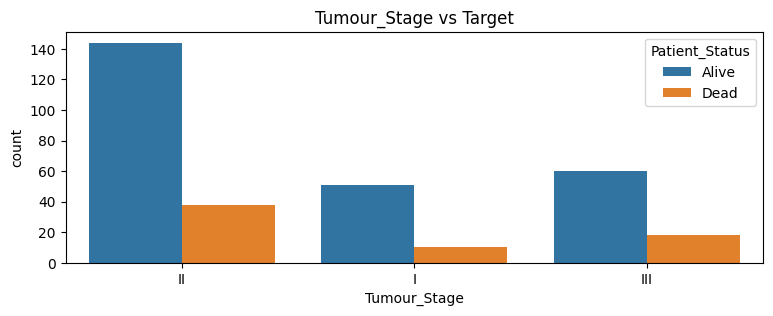

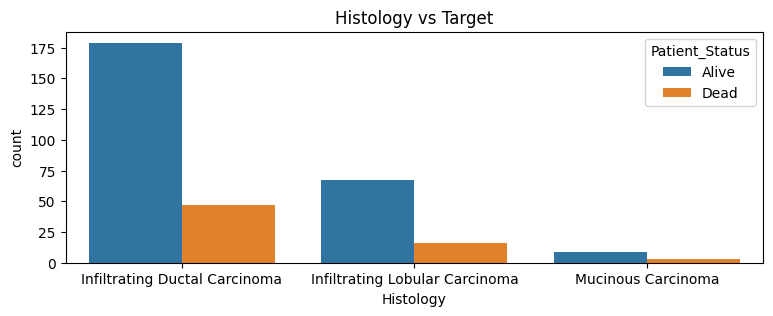

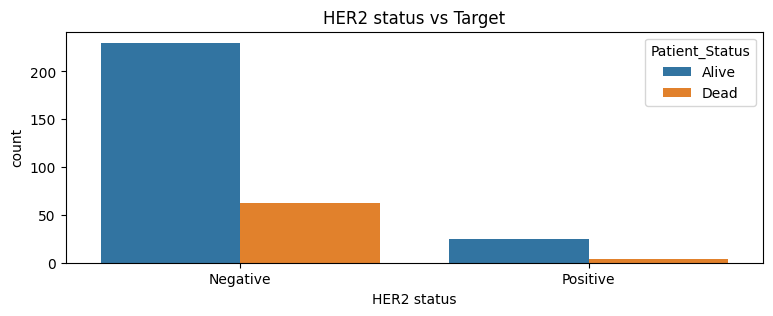

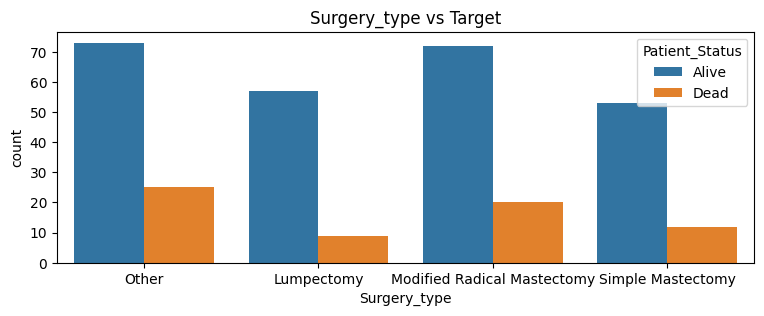

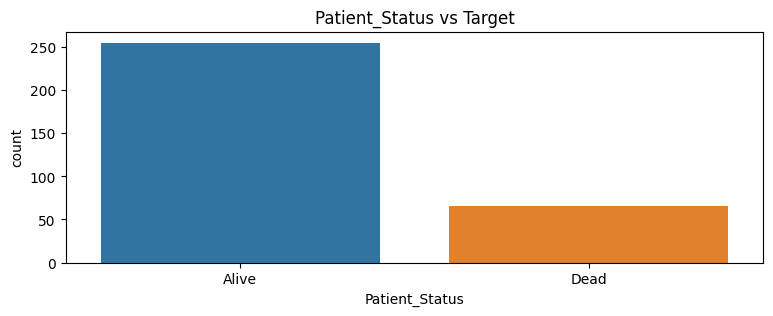

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(9,3))
    sns.countplot(x=col, hue='Patient_Status', data=df)
    plt.title(f'{col} vs Target')
    plt.show()

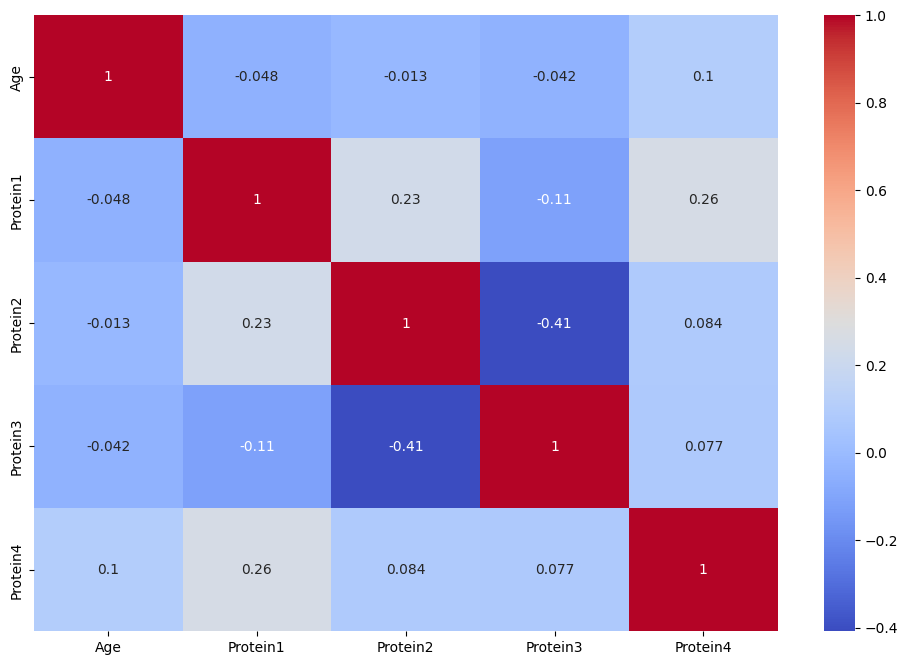

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

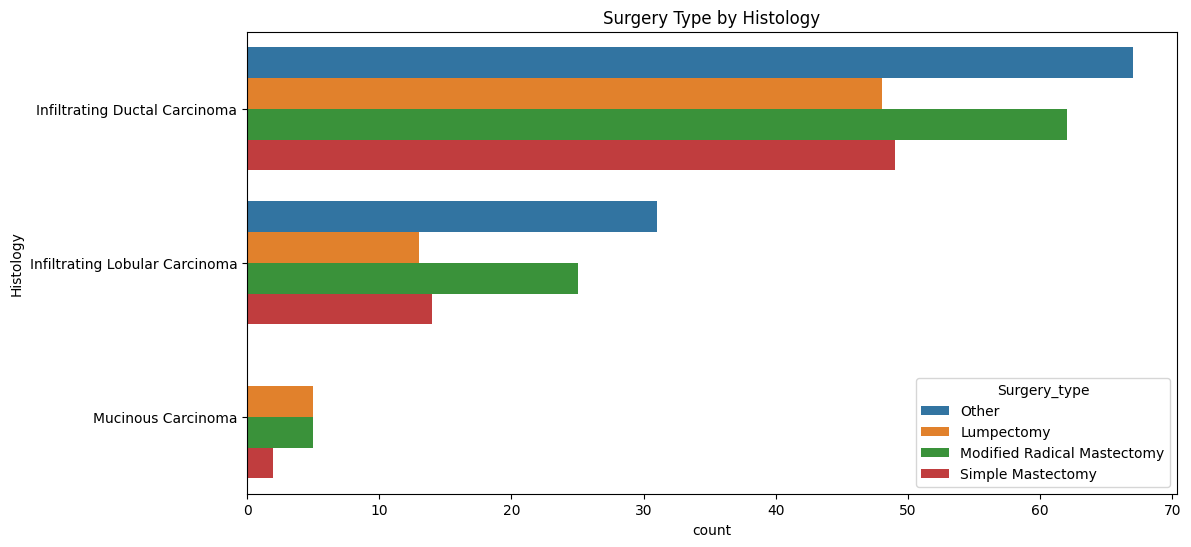

In [ ]:
# 3. Histology Type vs Surgery Type
plt.figure(figsize=(12, 6))
sns.countplot(y='Histology', hue='Surgery_type', data=df)
plt.title('Surgery Type by Histology')
plt.show()

In [ ]:
df.columns

Index(['Age', 'Gender', 'Protein1', 'Protein2', 'Protein3', 'Protein4',
       'Tumour_Stage', 'Histology', 'HER2 status', 'Surgery_type',
       'Patient_Status'],
      dtype='object')

In [ ]:
df['Tumour_Stage'].value_counts()

Tumour_Stage
II     182
III     78
I       61
Name: count, dtype: int64

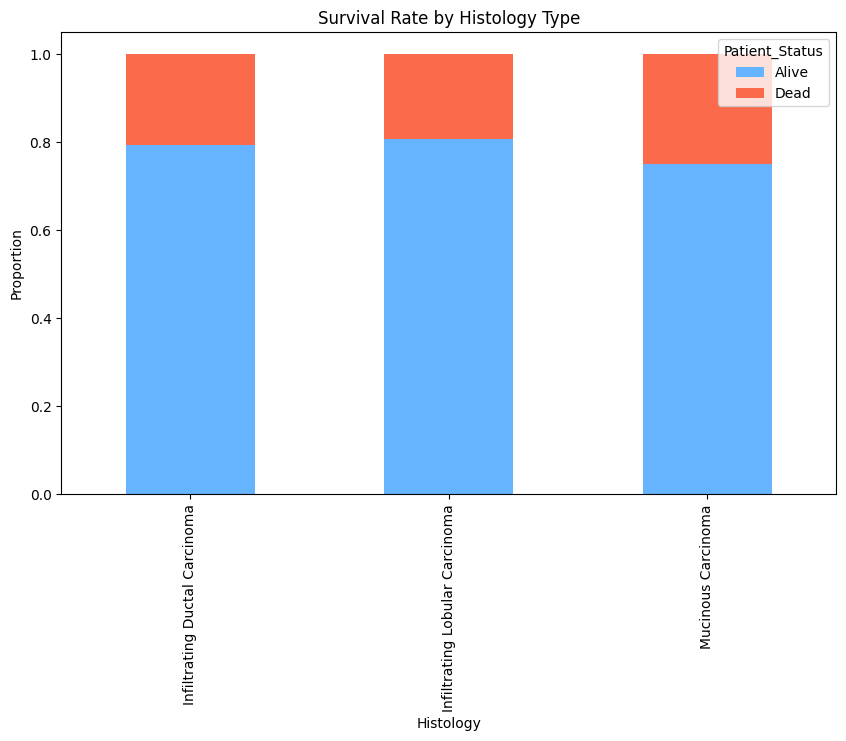

In [ ]:
# Relationship between Histology and Survival
hist_table = pd.crosstab(df['Histology'], df['Patient_Status'], normalize='index')
hist_table.plot(kind='bar', stacked=True, figsize=(10,6), color=['#66b3ff','#fb6a4a'])
plt.title('Survival Rate by Histology Type')
plt.ylabel('Proportion')
plt.show()

In [ ]:
df_num.skew()

Age         0.288271
Protein1   -0.262823
Protein2   -0.191931
Protein3    0.560671
Protein4   -0.394610
dtype: float64

In [ ]:
skew_vals = df[num_cols].skew()
skew_cols = skew_vals[skew_vals > 1].index

for col in skew_cols:
    df[col] = np.log1p(df[col])